# 🔍 机器学习实战：DBSCAN 聚类 (Density-Based Clustering)

## 1. 为什么我们需要 DBSCAN？

> **K-Means 的死穴**：它是基于"距离" (Distance) 的，假设簇是圆形的 (Spherical)。
> **DBSCAN 的优势**：它是基于"密度" (Density) 的，可以发现任意形状的簇 (比如弯月形)，并且能自动识别**噪音 (Noise)**。

### 核心概念 (The Party Analogy 🍺)
想象你在一个广场上找"圈子" (Clusters)：

1.  **Eps (ε)**: **听力半径**。如果在 1 米之内能听到对方说话，你们就算"挨得近"。
2.  **Min_Samples**: **成团门槛**。如果 1 米之内至少有 4 个人，你们就是一个"核心圈子" (Core Point)。
3.  **Noise (-1)**: **孤独患者**。半径之内没人，或者人不够凑一桌麻将，你就是离群点。

---

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_blobs

# 解决中文乱码
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## 2. K-Means 的尴尬瞬间 (The Fail Case)

我们生成一个"双月牙"数据集 (Make Moons)，看看 K-Means 会怎么切它。

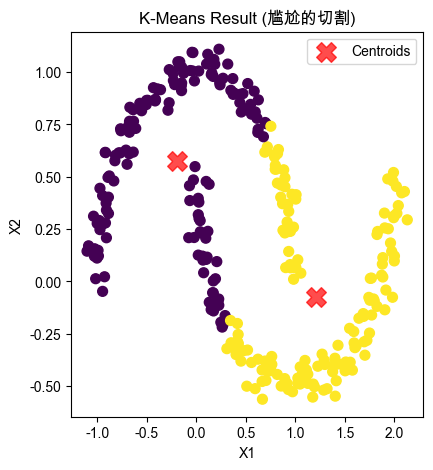

In [6]:
# 1. 生成数据
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# 2. K-Means 强行聚类 (k=2)
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

# 3. 可视化
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=50)

# 🔥 画出质心 (Centroids)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroids')
plt.legend()

plt.title('K-Means Result (尴尬的切割)')
plt.xlabel('X1')
plt.ylabel('X2');

> **观察 & 思考**: 
> *   看那两个红色的 **X** (质心)。K-Means 的逻辑是：**"谁离我近，谁就是我的人"**。
> *   它在两个月亮中间画了一条隐形的"分界线" (Voronoi Boundary)。
> *   但月亮是弯的！直线切不开弯月亮。这就是为什么它败了。

## 3. DBSCAN 拯救世界 🦸‍♂️

**关键步骤**: 
1. **Scaling (必须!)**: DBSCAN 基于距离，如果 x 轴是 0-1，y 轴是 0-10000，它会彻底失效。
2. **调参 (Eps, Min_Samples)**: 这是个手艺活。

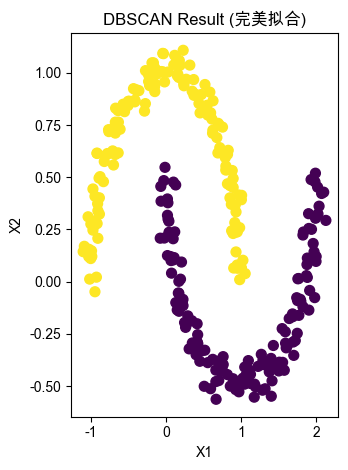

In [7]:
# 1. 数据标准化 (StandardScaler is MUST)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. DBSCAN 聚类
# eps=0.3: 半径 0.3 (Standard Deviation)
# min_samples=5: 至少 5 个点才算一伙
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

# 3. 可视化对比
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='viridis', s=50)
plt.title(f'DBSCAN Result (完美拟合)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.tight_layout()
plt.show()

## 4. 寻找异常值 (Outlier Detection) 🕵️

DBSCAN 最酷的功能是：它不需要你指定簇的数量，而且它会自动把那些"不合群"的点标记为 **-1**。

让我们模拟一些明显的噪音点来看看。

捕获到 3 个异常点 (Noise Points)


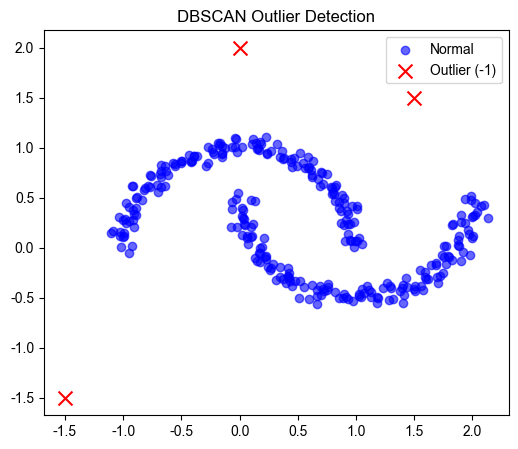

In [8]:
# 1. 制造一些捣乱的数据 (Outliers)
outliers = np.array([[1.5, 1.5], [-1.5, -1.5], [0, 2]])
X_dirty = np.vstack([X, outliers]) # 把噪音加进去

# 2. 重新标准化 & 训练
X_dirty_scaled = scaler.fit_transform(X_dirty)
dbscan_dirty = DBSCAN(eps=0.3, min_samples=5)
labels_dirty = dbscan_dirty.fit_predict(X_dirty_scaled)

# 3. 看看谁被标成了 -1 ?
n_noise = list(labels_dirty).count(-1)
print(f"捕获到 {n_noise} 个异常点 (Noise Points)")

# 4. 画图 (红色代表异常值)
plt.figure(figsize=(6, 5))
# 正常点
plt.scatter(X_dirty[labels_dirty != -1][:, 0], X_dirty[labels_dirty != -1][:, 1], c='blue', label='Normal', alpha=0.6)
# 异常点 (加大加粗)
plt.scatter(X_dirty[labels_dirty == -1][:, 0], X_dirty[labels_dirty == -1][:, 1], c='red', s=100, marker='x', label='Outlier (-1)')
plt.legend()
plt.title('DBSCAN Outlier Detection');

## 5. 挑战 (Exercise) 💪

调整 `eps` 和 `min_samples`，看看会发生什么？

1.  如果 `eps` 设得太小 (比如 0.1)，会发生什么？(提示：大家都很孤独)
2.  如果 `eps` 设得太大 (比如 1.0)，会发生什么？(提示：四海之内皆兄弟)

尝试修改上面的代码验证你的猜想！

捕获到 124 个异常点 (Noise Points)


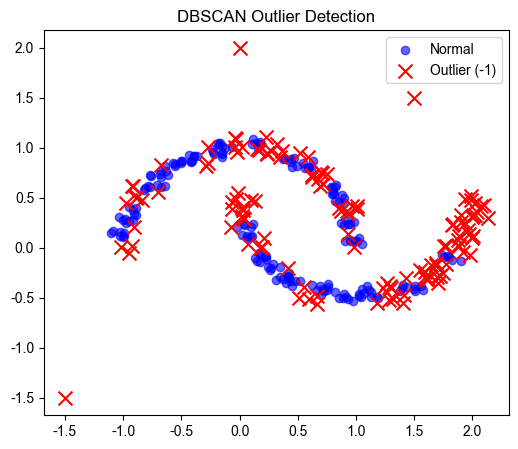

In [9]:
# 2. 重新标准化 & 训练
X_dirty_scaled = scaler.fit_transform(X_dirty)
dbscan_dirty = DBSCAN(eps=0.1, min_samples=5)
labels_dirty = dbscan_dirty.fit_predict(X_dirty_scaled)

# 3. 看看谁被标成了 -1 ?
n_noise = list(labels_dirty).count(-1)
print(f"捕获到 {n_noise} 个异常点 (Noise Points)")

# 4. 画图 (红色代表异常值)
plt.figure(figsize=(6, 5))
# 正常点
plt.scatter(X_dirty[labels_dirty != -1][:, 0], X_dirty[labels_dirty != -1][:, 1], c='blue', label='Normal', alpha=0.6)
# 异常点 (加大加粗)
plt.scatter(X_dirty[labels_dirty == -1][:, 0], X_dirty[labels_dirty == -1][:, 1], c='red', s=100, marker='x', label='Outlier (-1)')
plt.legend()
plt.title('DBSCAN Outlier Detection');

捕获到 3 个异常点 (Noise Points)


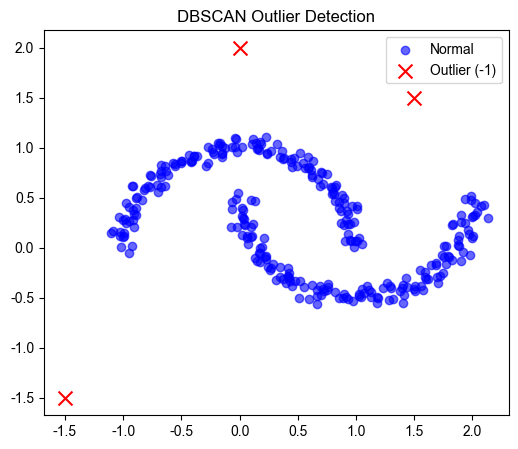

In [13]:
# 2. 重新标准化 & 训练
X_dirty_scaled = scaler.fit_transform(X_dirty)
dbscan_dirty = DBSCAN(eps=1, min_samples=10)
labels_dirty = dbscan_dirty.fit_predict(X_dirty_scaled)

# 3. 看看谁被标成了 -1 ?
n_noise = list(labels_dirty).count(-1)
print(f"捕获到 {n_noise} 个异常点 (Noise Points)")

# 4. 画图 (红色代表异常值)
plt.figure(figsize=(6, 5))
# 正常点
plt.scatter(X_dirty[labels_dirty != -1][:, 0], X_dirty[labels_dirty != -1][:, 1], c='blue', label='Normal', alpha=0.6)
# 异常点 (加大加粗)
plt.scatter(X_dirty[labels_dirty == -1][:, 0], X_dirty[labels_dirty == -1][:, 1], c='red', s=100, marker='x', label='Outlier (-1)')
plt.legend()
plt.title('DBSCAN Outlier Detection');